# DNN: analysis with Keras of 2D data

# Keras Tuner
check https://keras.io/keras_tuner/getting_started/ or just pip install keras-tuner -q

install tensorflow


In [1]:
!pip install keras-tuner -q

In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import keras_tuner
from keras.models import Sequential
from keras.layers import Dense, Dropout
#added
from keras import layers
import keras.optimizers

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler

%run useful.py

# training/validation/test fractions
perc_train = 0.8
perc_valid = 0.10
perc_test = 0.10
#  check it sums to 1
assert abs(perc_train + perc_valid + perc_test - 1.0) < 1e-12

2026-03-06 15:34:33.221621: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-06 15:34:33.222056: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 15:34:33.285844: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 15:34:34.630532: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

## Read data

(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 0
data: 12000
train: 9600
valid: 1200
test: 1200


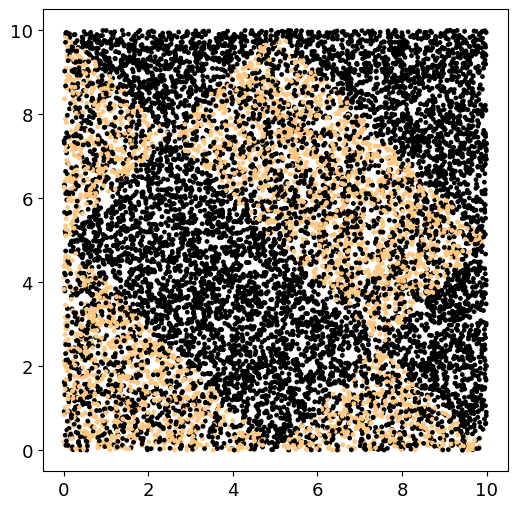

In [17]:
# Keras works with numpy arrays: just use them from the start

TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data_aug0.05",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels_aug0.05",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

plot_data(x,y)

## Split data and standardize (fit on train only)

In [18]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

Train: 9600 	 Validation: 1200 	 Test: 1200
after rescaling (train):
mean value= [ 2.03108363e-15  6.29479108e-15 -5.69839315e-15 -5.48011867e-15
 -4.38954428e-15 -3.07013674e-15 -4.04352477e-16 -1.01049493e-14] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


## Define the model with Keras / Tensorflow

In [20]:
def build_model(hp):
    model = Sequential()
    
    activation = hp.Choice("activation", ["relu", "sigmoid", "elu"])
    dropout = hp.Choice("dropout", [0.0, 0.1, 0.2])
    
    model.add(Dense(L,input_shape=(L,),activation=activation)) # first layer : L=8 neurons
    #model.add(Dense(20,input_shape=(L,),activation=activation)) # chat says that this is the first hidden layer of 20 and
    # input_shape = (L,) tells that the input layer is made of L neurons automatically
    model.add(Dense(20,activation=activation)) 
    model.add(Dropout(dropout)) # rate for neuron dropout, in order to add noise we assign a probability that a neuron
    # and its connections are dropped out. It's like training a dynamic neural network, we have randoms.
    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout))
    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout))
    model.add(Dense(1,activation="sigmoid"))
    #nepoch=200
    
    lr = hp.Choice("learning_rate", [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1])
    optimizer_name = hp.Choice("optimizer", ["adam","rmsprop","sgd"])

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = keras.optimizers.SGD(learning_rate=lr, nesterov=True)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [21]:
import keras_tuner

build_model(keras_tuner.HyperParameters())

<Sequential name=sequential_3, built=True>

In [22]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=30,
    #executions_per_trial=2,
    overwrite=True,
    directory="tuner_results",
    project_name="ex_1",
)

In [23]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'elu'], 'ordered': False}
dropout (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.1, 0.2], 'ordered': True}
learning_rate (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1], 'ordered': True}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}


In [24]:
tuner.search(x_train,y_train,epochs=50,validation_data=(x_valid,y_valid))

Trial 30 Complete [00h 00m 29s]
val_accuracy: 0.7699999809265137

Best val_accuracy So Far: 0.7791666388511658
Total elapsed time: 00h 13m 49s


## Training

In [25]:
# Get the top 2 hyperparameters.
best_hps = tuner.get_best_hyperparameters(5)
# Build the model with the best hp.
model = build_model(best_hps[0])
# Fit with the entire dataset.
#x_all = np.concatenate((x_train, x_valid))
#y_all = np.concatenate((y_train, y_valid))
#fit = model.fit(x=x_all, y=y_all, epochs=200)
fit = model.fit(x_train, y_train,
               epochs = 200, batch_size = 50, #size on which we are doing the gradients (batch_size= size of mini batches, the larger is batch size, the smoothest is our gradient, the smaller is the noisier is our gradient)
               validation_data=(x_valid,y_valid),
               verbose=2)

Epoch 1/200
192/192 - 2s - 8ms/step - accuracy: 0.7229 - loss: 0.5912 - val_accuracy: 0.7583 - val_loss: 0.5493
Epoch 2/200
192/192 - 0s - 2ms/step - accuracy: 0.7550 - loss: 0.5547 - val_accuracy: 0.7583 - val_loss: 0.5459
Epoch 3/200
192/192 - 0s - 2ms/step - accuracy: 0.7550 - loss: 0.5521 - val_accuracy: 0.7583 - val_loss: 0.5453
Epoch 4/200
192/192 - 0s - 2ms/step - accuracy: 0.7550 - loss: 0.5506 - val_accuracy: 0.7583 - val_loss: 0.5452
Epoch 5/200
192/192 - 0s - 2ms/step - accuracy: 0.7550 - loss: 0.5494 - val_accuracy: 0.7583 - val_loss: 0.5451
Epoch 6/200
192/192 - 0s - 2ms/step - accuracy: 0.7550 - loss: 0.5479 - val_accuracy: 0.7583 - val_loss: 0.5450
Epoch 7/200
192/192 - 0s - 2ms/step - accuracy: 0.7550 - loss: 0.5458 - val_accuracy: 0.7583 - val_loss: 0.5445
Epoch 8/200
192/192 - 0s - 2ms/step - accuracy: 0.7550 - loss: 0.5429 - val_accuracy: 0.7583 - val_loss: 0.5438
Epoch 9/200
192/192 - 0s - 2ms/step - accuracy: 0.7549 - loss: 0.5382 - val_accuracy: 0.7583 - val_loss:

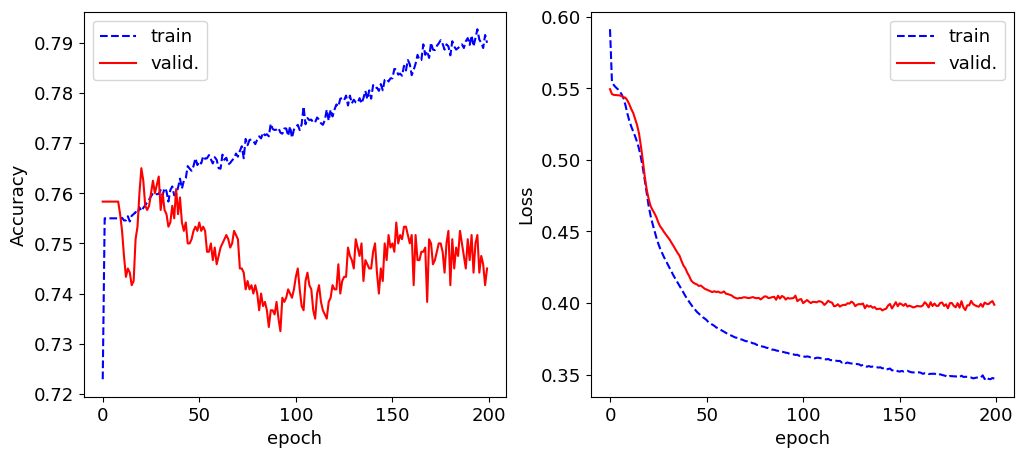

In [26]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

# Evaluation on the test set


In [27]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.4177
Final test accuracy: 0.7475


## Grid to show preditions

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step


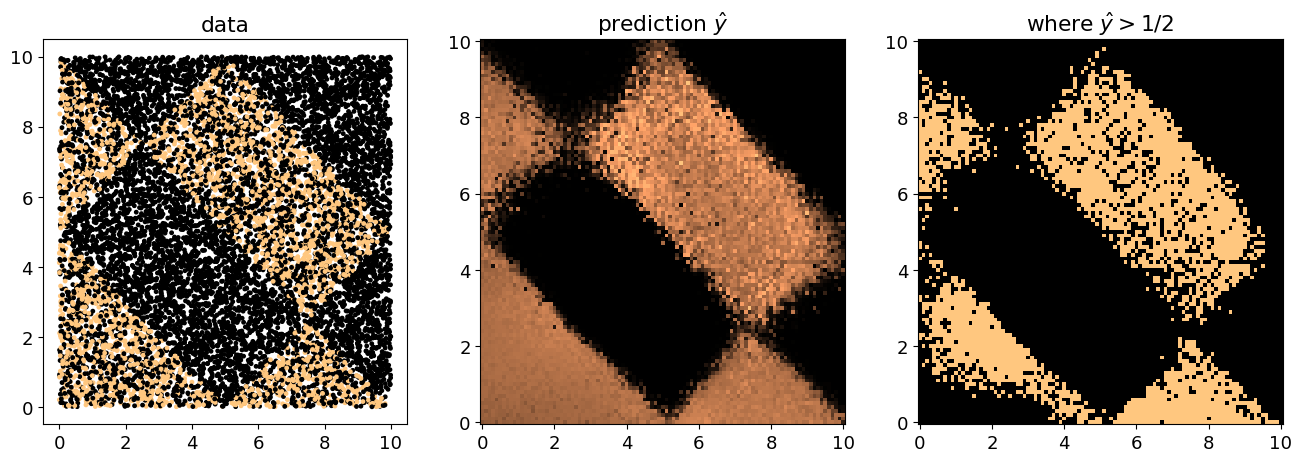

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [28]:
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")

In [49]:
#no of trainable parameter calculation
# total parameters , training sample to avoid overfitting
#accuracy= no.of correct predictioons/#no.of total predictions=(TP+TN)/(TP+TN+FP+FN)
#batch size if the sixe in which we do the gradients- the larger the batch size the 
#Ssmoother the gradient.The smaller the batch size, the noisier the gradient
#in case of Binary Cross entropy,if Loss starts from 0.7 its Random number generator i.e random prediction then learning.


(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 0
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 0
data: 12000
train: 9600
valid: 1200
test: 1200


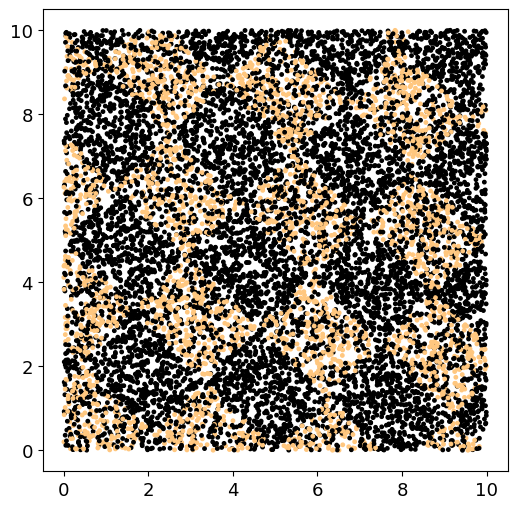

In [35]:
# Keras works with numpy arrays: just use them from the start

TYPE=4
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data_aug0.05",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels_aug0.05",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = int(perc_train * N)
N_valid = int(perc_valid * N)
N_test = N - N_train - N_valid
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}\ntest: {N_test}')

plot_data(x,y)

In [36]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

# split data into train/validation/test sets and check
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
(x_test, y_test) = (x[N_train+N_valid:],y[N_train+N_valid:])
print("Train:",len(x_train),"\t Validation:",len(x_valid),"\t Test:",len(x_test))


x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
#print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

x_valid_mean = np.mean(x_valid, axis=0)
x_valid_std = np.std(x_valid, axis=0)
#print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)

x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
#print("test stats before rescaling:\nmean value=", x_test_mean, "\nstd. dev.=", x_test_std)

x_train = Standardize(x_train, x_train_mean, x_train_std)
x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

Train: 9600 	 Validation: 1200 	 Test: 1200
after rescaling (train):
mean value= [ 2.03108363e-15  6.29479108e-15 -5.69839315e-15 -5.48011867e-15
 -4.38954428e-15 -3.07013674e-15 -4.04352477e-16 -1.01049493e-14] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


In [38]:
def build_model(hp):
    model = Sequential()
    
    activation = hp.Choice("activation", ["relu", "sigmoid", "elu"])
    dropout = hp.Choice("dropout", [0.0, 0.1, 0.2])
    
    model.add(Dense(L,input_shape=(L,),activation=activation)) # first layer : L=8 neurons
    #model.add(Dense(20,input_shape=(L,),activation=activation)) # chat says that this is the first hidden layer of 20 and
    # input_shape = (L,) tells that the input layer is made of L neurons automatically
    model.add(Dense(20,activation=activation)) 
    model.add(Dropout(dropout)) # rate for neuron dropout, in order to add noise we assign a probability that a neuron
    # and its connections are dropped out. It's like training a dynamic neural network, we have randoms.
    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout))
    model.add(Dense(20,activation=activation))
    model.add(Dropout(dropout))
    model.add(Dense(1,activation="sigmoid"))
    #nepoch=200
    
    lr = hp.Choice("learning_rate", [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1])
    optimizer_name = hp.Choice("optimizer", ["adam","rmsprop","sgd"])

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = keras.optimizers.SGD(learning_rate=lr, nesterov=True)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [39]:
import keras_tuner

build_model(keras_tuner.HyperParameters())

<Sequential name=sequential_2, built=True>

In [40]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=30,
    #executions_per_trial=2,
    overwrite=True,
    directory="tuner_results",
    project_name="ex_1",
)

In [41]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'elu'], 'ordered': False}
dropout (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.1, 0.2], 'ordered': True}
learning_rate (Choice)
{'default': 1e-06, 'conditions': [], 'values': [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1], 'ordered': True}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}


In [42]:
tuner.search(x_train,y_train,epochs=50,validation_data=(x_valid,y_valid))

Trial 30 Complete [00h 00m 30s]
val_accuracy: 0.737500011920929

Best val_accuracy So Far: 0.7408333420753479
Total elapsed time: 00h 14m 40s


In [43]:
# Get the top 2 hyperparameters.
best_hps = tuner.get_best_hyperparameters(5)
# Build the model with the best hp.
model = build_model(best_hps[0])
# Fit with the entire dataset.
#x_all = np.concatenate((x_train, x_valid))
#y_all = np.concatenate((y_train, y_valid))
#fit = model.fit(x=x_all, y=y_all, epochs=200)
fit = model.fit(x_train, y_train,
               epochs = 200, batch_size = 50, #size on which we are doing the gradients (batch_size= size of mini batches, the larger is batch size, the smoothest is our gradient, the smaller is the noisier is our gradient)
               validation_data=(x_valid,y_valid),
               verbose=2)

Epoch 1/200
192/192 - 1s - 6ms/step - accuracy: 0.7524 - loss: 0.5656 - val_accuracy: 0.7375 - val_loss: 0.5762
Epoch 2/200
192/192 - 0s - 2ms/step - accuracy: 0.7558 - loss: 0.5585 - val_accuracy: 0.7375 - val_loss: 0.5758
Epoch 3/200
192/192 - 0s - 2ms/step - accuracy: 0.7558 - loss: 0.5577 - val_accuracy: 0.7375 - val_loss: 0.5752
Epoch 4/200
192/192 - 0s - 2ms/step - accuracy: 0.7558 - loss: 0.5571 - val_accuracy: 0.7375 - val_loss: 0.5747
Epoch 5/200
192/192 - 0s - 2ms/step - accuracy: 0.7558 - loss: 0.5567 - val_accuracy: 0.7375 - val_loss: 0.5749
Epoch 6/200
192/192 - 0s - 2ms/step - accuracy: 0.7556 - loss: 0.5563 - val_accuracy: 0.7375 - val_loss: 0.5747
Epoch 7/200
192/192 - 0s - 2ms/step - accuracy: 0.7559 - loss: 0.5558 - val_accuracy: 0.7375 - val_loss: 0.5750
Epoch 8/200
192/192 - 0s - 2ms/step - accuracy: 0.7556 - loss: 0.5556 - val_accuracy: 0.7375 - val_loss: 0.5750
Epoch 9/200
192/192 - 0s - 2ms/step - accuracy: 0.7553 - loss: 0.5554 - val_accuracy: 0.7375 - val_loss:

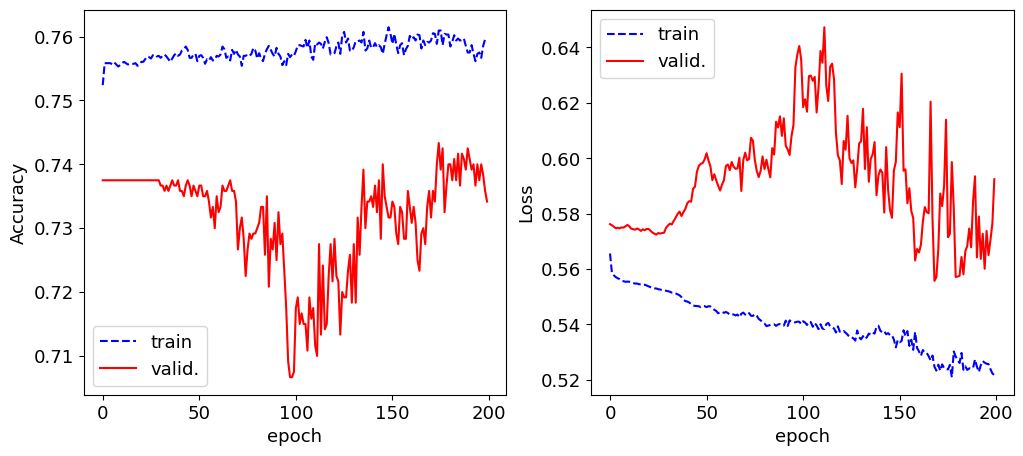

In [44]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

In [45]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.6368
Final test accuracy: 0.7342


319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step


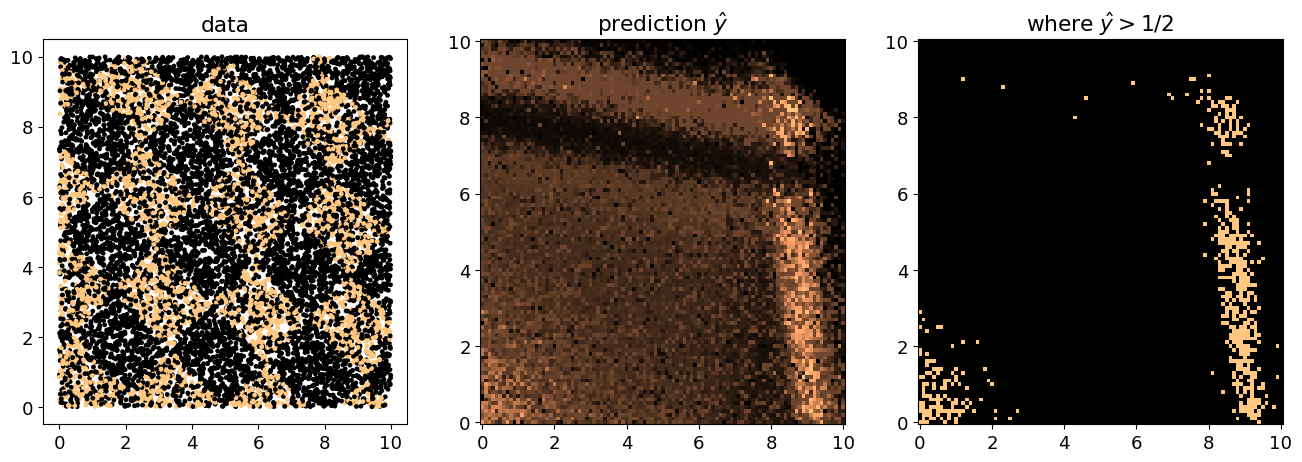

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [46]:
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")